<a href="https://colab.research.google.com/github/JMR825/Machine_learning-Notebook/blob/main/Copy_of_Stock_price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
path = kagglehub.dataset_download("camnugent/sandp500")
print('Data source import complete.')


Using Colab cache for faster access to the 'sandp500' dataset.
Data source import complete.


In [55]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV
import kagglehub

“Given historical daily OHLCV data for a chosen S&P 500 stock (e.g., AAL), predict the next day’s closing price using recent days’ prices and volume, and analyze model performance with visualizations and error metrics.”

In [56]:
stocks=pd.read_csv('/root/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv')
stocks

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


In [57]:
# 2. Data understanding
# Tickers used
print("No. of tickers used: ",stocks['Name'].nunique())
stocks['Date'] = pd.to_datetime(stocks['date'])
earliest_date = stocks['Date'].min()
latest_date = stocks['Date'].max()

# Print the interpreted result
print(f"My data goes from {earliest_date.strftime('%Y-%m-%d')} to {latest_date.strftime('%Y-%m-%d')}.")

No. of tickers used:  505
My data goes from 2013-02-08 to 2018-02-07.


In [58]:
# check for missing values
print(stocks['open'].isna().sum())
print(stocks['high'].isna().sum())
print(stocks['low'].isna().sum())
print(stocks['close'].isna().sum())
print(stocks['volume'].isna().sum())

11
8
8
0
0


In [59]:
# Imputer for later

In [60]:
stocks_cleaned = stocks.dropna(subset=['open', 'high', 'low'])

rows_removed = len(stocks) - len(stocks_cleaned)
print(f"Removed {rows_removed} rows with missing price data.")

Removed 11 rows with missing price data.


In [61]:
print(stocks_cleaned['open'].isna().sum())
print(stocks_cleaned['high'].isna().sum())
print(stocks_cleaned['low'].isna().sum())
print(stocks['close'].isna().sum())
print(stocks['volume'].isna().sum())

0
0
0
0
0


In [62]:
target_stock='AAPL'
single_stock=stocks[stocks['Name']==target_stock]
single_stock

,date,open,high,low,close,volume,Name,Date
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,2013-02-08
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,2013-02-11
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,2013-02-12
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,2013-02-13
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,2013-02-14
...,...,...,...,...,...,...,...,...
2513,2018-02-01,167.1650,168.6200,166.7600,167.7800,47230787,AAPL,2018-02-01
2514,2018-02-02,166.0000,166.8000,160.1000,160.5000,86593825,AAPL,2018-02-02
2515,2018-02-05,159.1000,163.8800,156.0000,156.4900,72738522,AAPL,2018-02-05
2516,2018-02-06,154.8300,163.7200,154.0000,163.0300,68243838,AAPL,2018-02-06


In [63]:
single_stock = single_stock.sort_values('Date', ascending=True)
single_stock['target'] = single_stock['close'].shift(-1)
single_stock.dropna(subset=['target'], inplace=True)


In [64]:
single_stock['return'] = single_stock['close'].pct_change()
single_stock['close_lag_1'] = single_stock['close'].shift(1)
single_stock['close_lag_2'] = single_stock['close'].shift(2)
single_stock['close_lag_3'] = single_stock['close'].shift(3)
single_stock['close_lag_5'] = single_stock['close'].shift(5)


In [65]:
single_stock['return_lag_1'] = single_stock['return'].shift(1)
single_stock['return_lag_2'] = single_stock['return'].shift(2)
single_stock['return_lag_3'] = single_stock['return'].shift(3)

In [66]:
single_stock['close_roll_mean_5'] = single_stock['close'].rolling(window=5).mean()
single_stock['close_roll_mean_10'] = single_stock['close'].rolling(window=10).mean()

In [67]:
single_stock['close_roll_std_5'] = single_stock['close'].rolling(window=5).std()
single_stock['close_roll_std_10'] = single_stock['close'].rolling(window=10).std()

In [68]:
single_stock['volume_roll_mean_5'] = single_stock['volume'].rolling(window=5).mean()

In [69]:
feature_cols = [
    'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5',
    'return_lag_1', 'return_lag_2', 'return_lag_3',
    'close_roll_mean_5', 'close_roll_mean_10',
    'close_roll_std_5', 'close_roll_std_10',
    'volume_roll_mean_5'  # only if you created it
]

single_stock = single_stock.dropna(subset=feature_cols + ['target'])

In [77]:
X = single_stock[feature_cols]
y = single_stock['target']
dates = single_stock['Date']

In [79]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
x_train,x_test,y_train,y_test,dates_train, dates_test =train_test_split(X,y,dates,test_size=0.2,random_state=42)
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)

In [72]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2  = r2_score(y_test, y_pred)

In [73]:
print(mae)
print(rmse)
print(r2)

1.6123218400000014
2.1660390901387023
0.9949602710481494


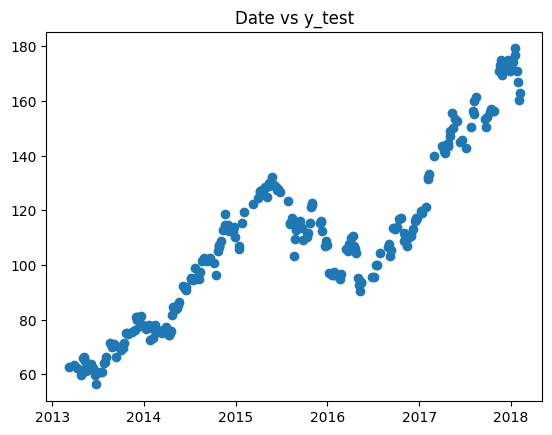

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.title("Date vs y_test")
plt.scatter(dates_test, y_test)
plt.show()

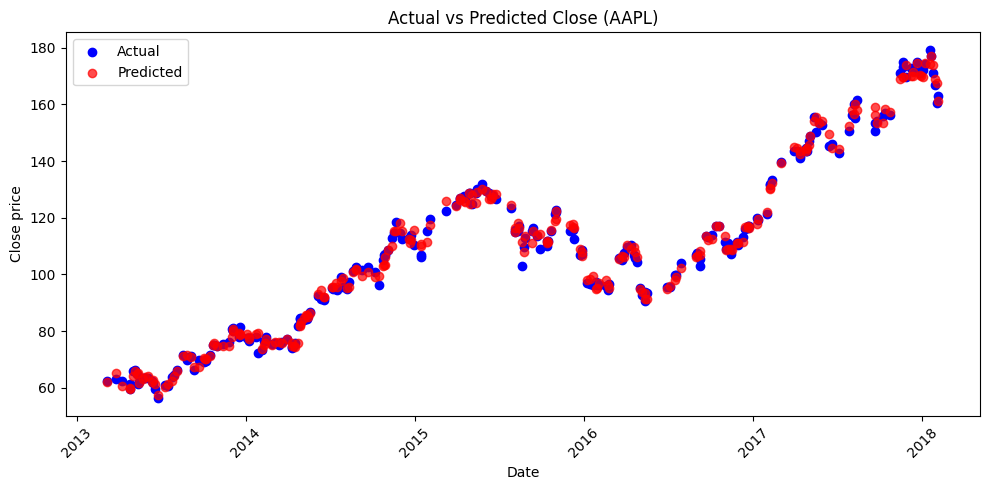

In [85]:
plt.figure(figsize=(10, 5))
plt.scatter(dates_test, y_test, label='Actual', color='blue')
plt.scatter(dates_test, y_pred, label='Predicted', color='red', alpha=0.7)
plt.title('Actual vs Predicted Close (AAPL)')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()